In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as  sns
from sklearn.model_selection import train_test_split

dt = pd.read_csv("deliveries_train.csv")
dt.head()

,order_id,order_time,main_dish,order_price,restaurant_lat,restaurant_lng,customer_lat,customer_lng,delivery_neighborhood,weather,traffic_level,restaurant_busy_level,courier_name,courier_vehicle,customer_first_name,app_version,delivery_time_minutes
0,DT04768,2026-02-08 08:52:31,poke_bowl,47.49,-23.561684,-46.655981,-23.576519,-46.680050,Itaim Bibi,rain,low,low,Gabriel,bike,Julia,5.20.0,56
1,DT01115,2026-03-11 14:46:39,ramen,46.41,-23.561684,-46.655981,-23.537814,-46.573183,Tatuape,storm,low,low,Carla,motorcycle,Otavio,5.20.0,71
2,DT00061,2026-03-29 13:56:10,feijoada,52.50,-23.561684,-46.655981,-23.543447,-46.661227,Perdizes,cloudy,low,medium,Marcos,motorcycle,Yasmin,6.0.0,50
3,DT02173,2026-04-17 12:15:02,ramen,38.13,-23.561684,-46.655981,-23.537306,-46.673415,Perdizes,cloudy,medium,medium,Julia,motorcycle,Bruno,5.21.2,49
4,DT04066,2026-02-27 14:09:33,classic_burger,37.22,-23.561684,-46.655981,-23.540271,-46.576867,Tatuape,clear,low,low,Bruno,motorcycle,Igor,5.20.0,50


In [ ]:
print(dt.info())
print("+"*100, ('\n'))
print(dt.describe())
print("+"*100, ('\n'))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               4000 non-null   object 
 1   order_time             4000 non-null   object 
 2   main_dish              4000 non-null   object 
 3   order_price            4000 non-null   float64
 4   restaurant_lat         4000 non-null   float64
 5   restaurant_lng         4000 non-null   float64
 6   customer_lat           4000 non-null   float64
 7   customer_lng           4000 non-null   float64
 8   delivery_neighborhood  4000 non-null   object 
 9   weather                4000 non-null   object 
 10  traffic_level          4000 non-null   object 
 11  restaurant_busy_level  4000 non-null   object 
 12  courier_name           4000 non-null   object 
 13  courier_vehicle        4000 non-null   object 
 14  customer_first_name    4000 non-null   object 
 15  app_

In [ ]:
dt.dtypes

,0
order_id,object
order_time,object
main_dish,object
order_price,float64
restaurant_lat,float64
restaurant_lng,float64
customer_lat,float64
customer_lng,float64
delivery_neighborhood,object
weather,object


In [ ]:
dt.isna().sum()

,0
order_id,0
order_time,0
main_dish,0
order_price,0
restaurant_lat,0
restaurant_lng,0
customer_lat,0
customer_lng,0
delivery_neighborhood,0
weather,0


In [ ]:
dt['weather'].value_counts()

,count
weather,
clear,2016
cloudy,1085
rain,706
storm,193


In [ ]:

dt['traffic_level'].value_counts()

,count
traffic_level,
low,1801
medium,1627
high,572


In [ ]:
dt['delivery_neighborhood'].value_counts()

,count
delivery_neighborhood,
Bela Vista,419
Jardins,408
Consolacao,372
Vila Mariana,346
Pinheiros,337
Moema,302
Itaim Bibi,290
Perdizes,254
Liberdade,241


In [ ]:

dt['app_version'].value_counts()

,count
app_version,
5.20.0,692
5.21.2,685
5.19.1,670
6.0.0,656
5.18.0,652
5.22.0,645


### 1. Distribution of Delivery Time

/tmp/ipykernel_1858/129395716.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(dt['delivery_time_minutes'], kde=True, bins=30, palette='viridis')


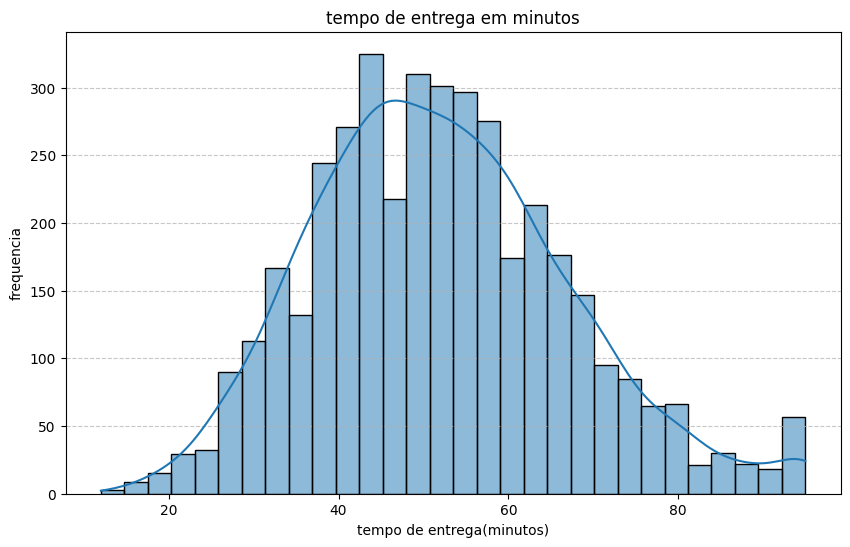

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(dt['delivery_time_minutes'], kde=True, bins=30, palette='viridis')
plt.title('tempo de entrega em minutos')
plt.xlabel('tempo de entrega(minutos)')
plt.ylabel('frequencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 2. Delivery Time by Main Dish

/tmp/ipykernel_1858/3416600515.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='main_dish', y='delivery_time_minutes', data=dt, palette='coolwarm')


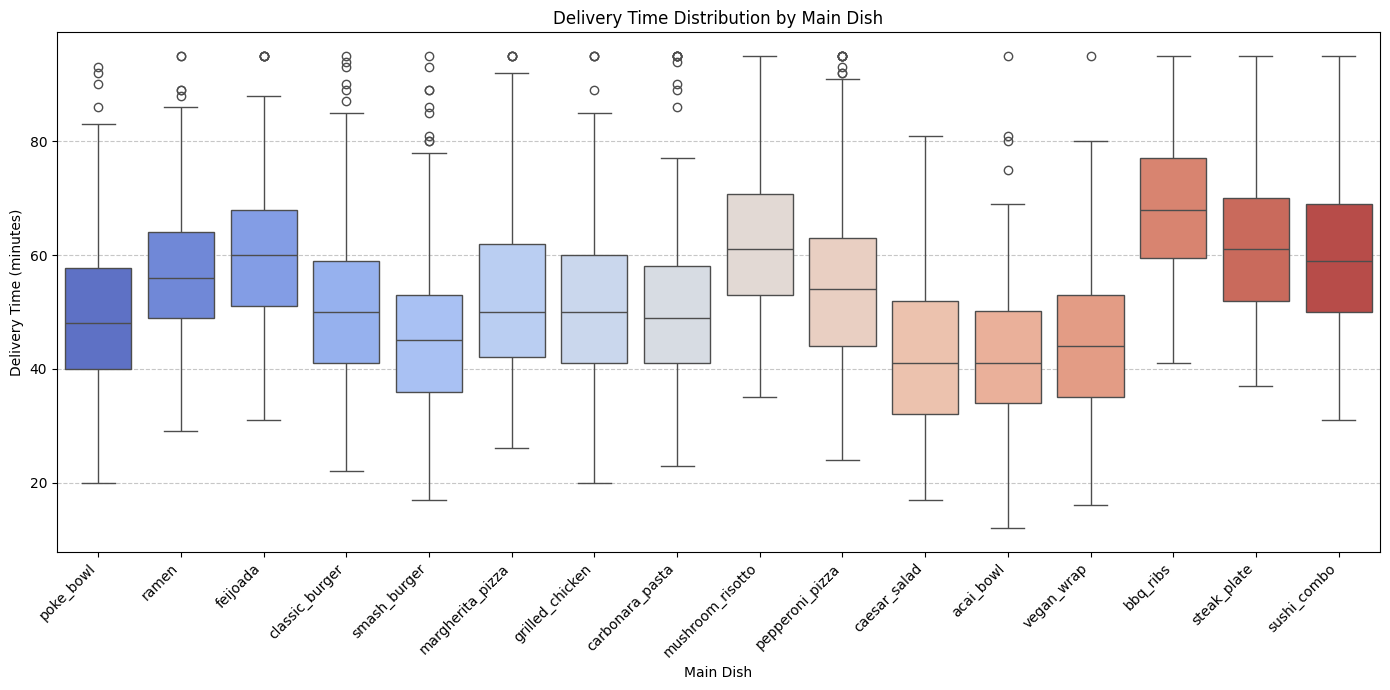

In [ ]:
plt.figure(figsize=(14, 7))
sns.boxplot(x='main_dish', y='delivery_time_minutes', data=dt, palette='coolwarm')
plt.title('Delivery Time Distribution by Main Dish')
plt.xlabel('Main Dish')
plt.ylabel('Delivery Time (minutes)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1858/3455238938.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='weather', y='delivery_time_minutes', data=dt, palette='Paired')


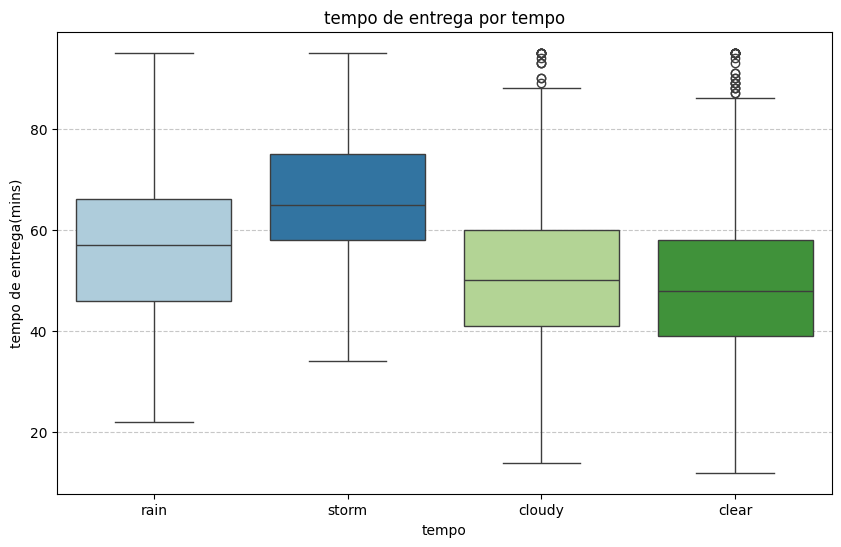

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='weather', y='delivery_time_minutes', data=dt, palette='Paired')
plt.title('tempo de entrega por tempo')
plt.xlabel('tempo')
plt.ylabel('tempo de entrega(mins)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Análise dos Quartis do Tempo de Entrega por Categorias

Vamos calcular e exibir os quartis (25%, 50% - mediana, 75%) do tempo de entrega para diferentes categorias, como 'prato principal' e 'condições climáticas'. Isso nos dará uma visão numérica da distribuição.

In [ ]:
print("\n--- Quartis do Tempo de Entrega por Prato Principal ---")
quartis_main_dish = dt.groupby('main_dish')['delivery_time_minutes'].quantile([0.25, 0.5, 0.75]).unstack()
display(quartis_main_dish)

print("\n--- Quartis do Tempo de Entrega por Condições Climáticas ---")
quartis_weather = dt.groupby('weather')['delivery_time_minutes'].quantile([0.25, 0.5, 0.75]).unstack()
display(quartis_weather)



--- Quartis do Tempo de Entrega por Prato Principal ---


,0.25,0.50,0.75
main_dish,,,
acai_bowl,34.0,41.0,50.25
bbq_ribs,59.5,68.0,77.00
caesar_salad,32.0,41.0,52.00
carbonara_pasta,41.0,49.0,58.00
classic_burger,41.0,50.0,59.00
feijoada,51.0,60.0,68.00
grilled_chicken,41.0,50.0,60.00
margherita_pizza,42.0,50.0,62.00
mushroom_risotto,53.0,61.0,70.75



--- Quartis do Tempo de Entrega por Condições Climáticas ---


,0.25,0.50,0.75
weather,,,
clear,39.0,48.0,58.0
cloudy,41.0,50.0,60.0
rain,46.0,57.0,66.0
storm,58.0,65.0,75.0


In [ ]:
od = pd.read_csv("orders_train.csv")

### 1. Preparação dos Dados: Converter `order_time` para Datetime

Para filtrar por tempo, precisamos garantir que a coluna `order_time` esteja no formato adequado de data e hora.

In [ ]:
# Convertendo 'order_time' para datetime no DataFrame 'dt'
dt['order_time'] = pd.to_datetime(dt['order_time'])

# Exibindo os tipos de dados para verificar a conversão
print(dt.dtypes)


order_id                         object
order_time               datetime64[ns]
main_dish                        object
order_price                     float64
restaurant_lat                  float64
restaurant_lng                  float64
customer_lat                    float64
customer_lng                    float64
delivery_neighborhood            object
weather                          object
traffic_level                    object
restaurant_busy_level            object
courier_name                     object
courier_vehicle                  object
customer_first_name              object
app_version                      object
delivery_time_minutes             int64
dtype: object


### 2. Função para Calcular Faturamento por Produto com Filtros

A seguir, uma função que permite calcular o faturamento total de cada produto (`main_dish`), aplicando filtros opcionais por data (início e fim), bairro de entrega, veículo do entregador e nível de tráfego.

In [ ]:
def calcular_faturamento_por_produto_com_filtros(
    dataframe,
    data_inicio=None,
    data_fim=None,
    bairro=None,
    veiculo_entregador=None,
    nivel_trafego=None
):
    df_filtrado = dataframe.copy()

    if data_inicio:
        df_filtrado = df_filtrado[df_filtrado['order_time'] >= data_inicio]
    if data_fim:
        df_filtrado = df_filtrado[df_filtrado['order_time'] <= data_fim]
    if bairro:
        df_filtrado = df_filtrado[df_filtrado['delivery_neighborhood'] == bairro]
    if veiculo_entregador:
        df_filtrado = df_filtrado[df_filtrado['courier_vehicle'] == veiculo_entregador]
    if nivel_trafego:
        df_filtrado = df_filtrado[df_filtrado['traffic_level'] == nivel_trafego]

    faturamento_por_produto = df_filtrado.groupby('main_dish')['order_price'].sum().sort_values(ascending=False)
    return faturamento_por_produto

# --- Exemplos de Uso ---

print("\n--- Faturamento Total por Produto (sem filtros) ---")
faturamento_total = calcular_faturamento_por_produto_com_filtros(dt)
display(faturamento_total)

print("\n--- Faturamento por Produto para Entregas no Itaim Bibi ---")
faturamento_itaim_bibi = calcular_faturamento_por_produto_com_filtros(dt, bairro='Itaim Bibi')
display(faturamento_itaim_bibi)

print("\n--- Faturamento por Produto para Entregas de Moto com Tráfego Alto ---")
faturamento_moto_alto_trafego = calcular_faturamento_por_produto_com_filtros(
    dt, veiculo_entregador='motorcycle', nivel_trafego='high'
)
display(faturamento_moto_alto_trafego)

print("\n--- Faturamento por Produto para um Período Específico (Ex: Março de 2026) ---")
faturamento_marco_2026 = calcular_faturamento_por_produto_com_filtros(
    dt,
    data_inicio='2026-03-01',
    data_fim='2026-03-31'
)
display(faturamento_marco_2026)



--- Faturamento Total por Produto (sem filtros) ---


,order_price
main_dish,
pepperoni_pizza,16693.13
margherita_pizza,16426.58
sushi_combo,15217.91
classic_burger,15216.50
poke_bowl,13478.04
carbonara_pasta,12216.98
smash_burger,11806.97
grilled_chicken,10152.80
ramen,9276.45



--- Faturamento por Produto para Entregas no Itaim Bibi ---


,order_price
main_dish,
margherita_pizza,1346.17
pepperoni_pizza,1199.56
sushi_combo,1057.58
carbonara_pasta,998.29
poke_bowl,989.14
classic_burger,880.91
grilled_chicken,846.78
steak_plate,809.03
ramen,797.33



--- Faturamento por Produto para Entregas de Moto com Tráfego Alto ---


,order_price
main_dish,
poke_bowl,1814.24
pepperoni_pizza,1624.36
margherita_pizza,1522.21
classic_burger,1291.67
carbonara_pasta,1228.55
grilled_chicken,1064.85
smash_burger,843.13
feijoada,837.41
caesar_salad,811.35



--- Faturamento por Produto para um Período Específico (Ex: Março de 2026) ---


,order_price
main_dish,
margherita_pizza,3356.06
classic_burger,3247.43
pepperoni_pizza,2843.18
sushi_combo,2407.69
poke_bowl,2351.20
bbq_ribs,2211.44
carbonara_pasta,2165.36
smash_burger,2144.29
ramen,2102.93


In [ ]:
print("-- produtos -- (deliveries_train.csv)")
print(dt.columns.tolist())
print("-- fidelidade -- (orders_train.csv)")
print(od.columns.tolist())

-- produtos -- (deliveries_train.csv)
['order_id', 'order_time', 'main_dish', 'order_price', 'restaurant_lat', 'restaurant_lng', 'customer_lat', 'customer_lng', 'delivery_neighborhood', 'weather', 'traffic_level', 'restaurant_busy_level', 'courier_name', 'courier_vehicle', 'customer_first_name', 'app_version', 'delivery_time_minutes']
-- fidelidade -- (orders_train.csv)
['order_id', 'customer_id', 'order_datetime', 'dish_name', 'dish_category', 'dish_price', 'delivery_fee', 'used_coupon', 'coupon_discount_value', 'payment_method', 'order_period', 'is_weekend', 'points_earned', 'points_balance_after_order', 'order_rating', 'customer_first_name', 'app_version']


In [ ]:
od

,order_id,customer_id,order_datetime,dish_name,dish_category,dish_price,delivery_fee,used_coupon,coupon_discount_value,payment_method,order_period,is_weekend,points_earned,points_balance_after_order,order_rating,customer_first_name,app_version
0,RW000001,CUST0558,2025-04-08 11:47:59,yakisoba,japanese,40.39,7.33,False,0.00,credit_card,lunch,False,48,591,4.0,Vanessa,6.0.0
1,RW000003,CUST0588,2025-10-03 21:32:34,acai_bowl,dessert,24.39,4.15,False,0.00,credit_card,dinner,False,29,1079,3.0,Paula,5.21.2
2,RW000004,CUST1040,2026-04-14 20:13:53,fresh_juice,drink,11.90,3.73,False,0.00,pix,dinner,False,16,1227,3.0,Natalia,5.22.0
3,RW000005,CUST0652,2025-12-21 21:04:51,grilled_chicken_salad,salad,41.59,7.41,False,0.00,credit_card,dinner,True,49,1034,NaN,Yasmin,6.0.0
4,RW000006,CUST0770,2025-06-04 14:43:12,classic_burger,burger,32.66,4.69,True,11.93,pix,lunch,False,25,526,3.0,Lucas,5.21.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22422,RW029996,CUST0182,2025-11-07 14:42:00,quinoa_salad,salad,41.96,7.70,True,12.44,debit_card,lunch,False,37,785,5.0,Elisa,5.18.0
22423,RW029997,CUST0307,2025-11-17 12:13:11,pudim,dessert,13.22,6.87,False,0.00,credit_card,lunch,False,20,1031,4.0,Natalia,5.20.0
22424,RW029998,CUST0729,2026-02-20 22:10:37,smash_burger,burger,30.43,7.61,False,0.00,debit_card,late_night,False,38,2408,4.0,Mariana,5.18.0
22425,RW029999,CUST0213,2025-04-21 11:57:08,pepperoni_pizza,pizza,60.81,5.21,True,5.33,debit_card,lunch,False,61,156,5.0,Yasmin,5.19.1


### Encontrando a Interseção entre os DataFrames `dt` e `od`

Vamos usar a coluna `order_id` para juntar os dois DataFrames (`dt` e `od`) e ver as informações combinadas de entregas e pedidos.

In [ ]:
df_merged = pd.merge(dt, od, on='customer_first_name', how='inner')
print("Interseção dos DataFrames 'dt' e 'od' com base em 'order_id':")
display(df_merged.head())

Interseção dos DataFrames 'dt' e 'od' com base em 'order_id':


,order_id_x,order_time,main_dish,order_price,restaurant_lat,restaurant_lng,customer_lat,customer_lng,delivery_neighborhood,weather,...,delivery_fee,used_coupon,coupon_discount_value,payment_method,order_period,is_weekend,points_earned,points_balance_after_order,order_rating,app_version_y
0,DT04768,2026-02-08 08:52:31,poke_bowl,47.49,-23.561684,-46.655981,-23.576519,-46.68005,Itaim Bibi,rain,...,3.23,False,0.00,pix,lunch,False,45,592,5.0,5.20.0
1,DT04768,2026-02-08 08:52:31,poke_bowl,47.49,-23.561684,-46.655981,-23.576519,-46.68005,Itaim Bibi,rain,...,3.96,True,9.94,credit_card,late_night,False,38,176,5.0,5.20.0
2,DT04768,2026-02-08 08:52:31,poke_bowl,47.49,-23.561684,-46.655981,-23.576519,-46.68005,Itaim Bibi,rain,...,4.86,True,8.77,credit_card,dinner,False,54,226,4.0,5.21.2
3,DT04768,2026-02-08 08:52:31,poke_bowl,47.49,-23.561684,-46.655981,-23.576519,-46.68005,Itaim Bibi,rain,...,3.58,False,0.00,credit_card,dinner,True,15,305,4.0,5.21.2
4,DT04768,2026-02-08 08:52:31,poke_bowl,47.49,-23.561684,-46.655981,-23.576519,-46.68005,Itaim Bibi,rain,...,4.80,False,0.00,credit_card,lunch,False,37,774,3.0,5.20.0


In [ ]:
dt.head()

,order_id,order_time,main_dish,order_price,restaurant_lat,restaurant_lng,customer_lat,customer_lng,delivery_neighborhood,weather,traffic_level,restaurant_busy_level,courier_name,courier_vehicle,customer_first_name,app_version,delivery_time_minutes
0,DT04768,2026-02-08 08:52:31,poke_bowl,47.49,-23.561684,-46.655981,-23.576519,-46.680050,Itaim Bibi,rain,low,low,Gabriel,bike,Julia,5.20.0,56
1,DT01115,2026-03-11 14:46:39,ramen,46.41,-23.561684,-46.655981,-23.537814,-46.573183,Tatuape,storm,low,low,Carla,motorcycle,Otavio,5.20.0,71
2,DT00061,2026-03-29 13:56:10,feijoada,52.50,-23.561684,-46.655981,-23.543447,-46.661227,Perdizes,cloudy,low,medium,Marcos,motorcycle,Yasmin,6.0.0,50
3,DT02173,2026-04-17 12:15:02,ramen,38.13,-23.561684,-46.655981,-23.537306,-46.673415,Perdizes,cloudy,medium,medium,Julia,motorcycle,Bruno,5.21.2,49
4,DT04066,2026-02-27 14:09:33,classic_burger,37.22,-23.561684,-46.655981,-23.540271,-46.576867,Tatuape,clear,low,low,Bruno,motorcycle,Igor,5.20.0,50


In [ ]:

dt['year'] = dt['order_time'].dt.year
dt['month'] = dt['order_time'].dt.month
dt['day'] = dt['order_time'].dt.day

display(dt[['order_time', 'year', 'month', 'day', 'main_dish', 'order_price']].head())


,order_time,year,month,day,main_dish,order_price
0,2026-02-08 08:52:31,2026,2,8,poke_bowl,47.49
1,2026-03-11 14:46:39,2026,3,11,ramen,46.41
2,2026-03-29 13:56:10,2026,3,29,feijoada,52.50
3,2026-04-17 12:15:02,2026,4,17,ramen,38.13
4,2026-02-27 14:09:33,2026,2,27,classic_burger,37.22


### 2. Aggregate Daily Revenue per Product

Next, we'll aggregate the data to get the total revenue for each `main_dish` on each `date`. This will form the basis of our time series for revenue prediction.

In [ ]:

daily_product_revenue = dt.groupby(['date', 'main_dish'])['order_price'].sum().reset_index()
daily_product_revenue = daily_product_revenue.rename(columns={'order_price': 'total_daily_revenue'})

print("Daily total revenue per main dish:")
display(daily_product_revenue.head())

unique_products = daily_product_revenue['main_dish'].unique()
print(f"\nUnique products for prediction: {len(unique_products)}")


Daily total revenue per main dish:


,date,main_dish,total_daily_revenue
0,2026-01-01,acai_bowl,26.13
1,2026-01-01,caesar_salad,67.14
2,2026-01-01,carbonara_pasta,41.56
3,2026-01-01,feijoada,124.76
4,2026-01-01,margherita_pizza,174.69



Unique products for prediction: 16


### 4. Define the RNN Model

We will define a simple RNN model using PyTorch's `nn.Module`. This model will take a sequence of `LOOK_BACK` days of scaled revenue as input and output a sequence of `FORECAST_HORIZON` days of scaled revenue.

In [ ]:
class ProductRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(ProductRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU() # Add ReLU activation

    def forward(self, x):
        # Initialize hidden state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Pass through RNN layer
        out, _ = self.rnn(x, h0)

        # Take the output from the last time step for prediction
        out = self.fc(out[:, -1, :])
        return self.relu(out) # Apply ReLU to ensure non-negative predictions

# Define model parameters
input_size = 1  # We have one feature: scaled revenue
hidden_size = 50 # Number of features in the hidden state
output_size = FORECAST_HORIZON # We want to predict FORECAST_HORIZON days
num_layers = 2 # Number of recurrent layers

# Initialize the model (example for one product)
model = ProductRNN(input_size, hidden_size, output_size, num_layers)
print("RNN Model Architecture:")
print(model)


RNN Model Architecture:
ProductRNN(
  (rnn): RNN(1, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=7, bias=True)
  (relu): ReLU()
)


### 5. Train the RNN Model

Now we will train an RNN model for each product's time series data. We'll use Mean Squared Error (MSE) as the loss function and Adam as the optimizer.

In [ ]:
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Training parameters
learning_rate = 0.001
num_epochs = 100
batch_size = 32

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Store trained models
trained_models = {}

for item in train_sequences:
    product = item['product']
    X_train_tensor = item['X'].to(device)
    y_train_tensor = item['y'].to(device)

    # Skip if no training data for product
    if X_train_tensor.shape[0] == 0:
        print(f"Skipping training for {product} due to no training data.")
        continue

    # Re-initialize model for each product to ensure independent training
    product_model = ProductRNN(input_size, hidden_size, output_size, num_layers).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(product_model.parameters(), lr=learning_rate)

    # Create DataLoader
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    print(f"\nTraining model for product: {product}")
    for epoch in range(num_epochs):
        product_model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = product_model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

        if (epoch+1) % 20 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

    trained_models[product] = product_model

print("\nAll models trained successfully!")


Using device: cpu

Training model for product: acai_bowl
Epoch [20/100], Loss: 0.0348
Epoch [40/100], Loss: 0.0452
Epoch [60/100], Loss: 0.0458
Epoch [80/100], Loss: 0.0517
Epoch [100/100], Loss: 0.0586

Training model for product: caesar_salad
Epoch [20/100], Loss: 0.0720
Epoch [40/100], Loss: 0.0889
Epoch [60/100], Loss: 0.0690
Epoch [80/100], Loss: 0.0631
Epoch [100/100], Loss: 0.0601

Training model for product: carbonara_pasta
Epoch [20/100], Loss: 0.0476
Epoch [40/100], Loss: 0.0511
Epoch [60/100], Loss: 0.0405
Epoch [80/100], Loss: 0.0201
Epoch [100/100], Loss: 0.0242

Training model for product: feijoada
Epoch [20/100], Loss: 0.0619
Epoch [40/100], Loss: 0.0561
Epoch [60/100], Loss: 0.0514
Epoch [80/100], Loss: 0.0629
Epoch [100/100], Loss: 0.0469

Training model for product: margherita_pizza
Epoch [20/100], Loss: 0.0358
Epoch [40/100], Loss: 0.0397
Epoch [60/100], Loss: 0.0253
Epoch [80/100], Loss: 0.0241
Epoch [100/100], Loss: 0.0314

Training model for product: pepperoni_piz

### 6. Evaluate and Make Predictions

Now, let's evaluate the trained models on the test sets and make predictions for the next 7 days for each product.

In [ ]:
def evaluate_and_predict(model, test_sequences, scalers, device, forecast_horizon=FORECAST_HORIZON):
    model.eval()
    all_predictions = {}
    all_actuals = {}

    with torch.no_grad():
        for item in test_sequences:
            product = item['product']
            X_test_tensor = item['X'].to(device)
            y_test_tensor = item['y'].to(device)

            if X_test_tensor.shape[0] == 0:
                continue # Skip if no test data for product

            predictions = model(X_test_tensor).cpu().numpy()
            actuals = y_test_tensor.cpu().numpy()

            # Inverse transform predictions and actuals
            scaler = scalers[product]
            # The predictions and actuals are already in shape (num_samples, forecast_horizon)
            # We need to reshape them to (num_samples * forecast_horizon, 1) for inverse_transform
            # then reshape back.

            reshaped_predictions = predictions.reshape(-1, 1)
            reshaped_actuals = actuals.reshape(-1, 1)

            inverse_predictions = scaler.inverse_transform(reshaped_predictions).reshape(predictions.shape)
            inverse_actuals = scaler.inverse_transform(reshaped_actuals).reshape(actuals.shape)

            all_predictions[product] = inverse_predictions
            all_actuals[product] = inverse_actuals

    return all_predictions, all_actuals

# Evaluate and predict for all products
product_predictions, product_actuals = evaluate_and_predict(model, test_sequences, scalers, device)

print("Predictions generated for the following products:")
for product_name, preds in product_predictions.items():
    print(f"- {product_name}: {preds.shape[0]} test sequences, each predicting {FORECAST_HORIZON} days.")

# Display a sample prediction
example_product = unique_products[0]
if example_product in product_predictions:
    print(f"\nExample prediction for {example_product} (first test sequence):")
    print("Predicted 7 days revenue:", product_predictions[example_product][0])
    print("Actual 7 days revenue:", product_actuals[example_product][0])


Predictions generated for the following products:
- acai_bowl: 26 test sequences, each predicting 7 days.
- caesar_salad: 26 test sequences, each predicting 7 days.
- carbonara_pasta: 26 test sequences, each predicting 7 days.
- feijoada: 26 test sequences, each predicting 7 days.
- margherita_pizza: 26 test sequences, each predicting 7 days.
- pepperoni_pizza: 26 test sequences, each predicting 7 days.
- poke_bowl: 26 test sequences, each predicting 7 days.
- ramen: 26 test sequences, each predicting 7 days.
- smash_burger: 26 test sequences, each predicting 7 days.
- sushi_combo: 26 test sequences, each predicting 7 days.
- bbq_ribs: 26 test sequences, each predicting 7 days.
- classic_burger: 26 test sequences, each predicting 7 days.
- grilled_chicken: 26 test sequences, each predicting 7 days.
- mushroom_risotto: 26 test sequences, each predicting 7 days.
- steak_plate: 26 test sequences, each predicting 7 days.
- vegan_wrap: 26 test sequences, each predicting 7 days.

Example pre

### 7. Visualize Predictions

Let's visualize the predictions for a few products to see how well the model performed.

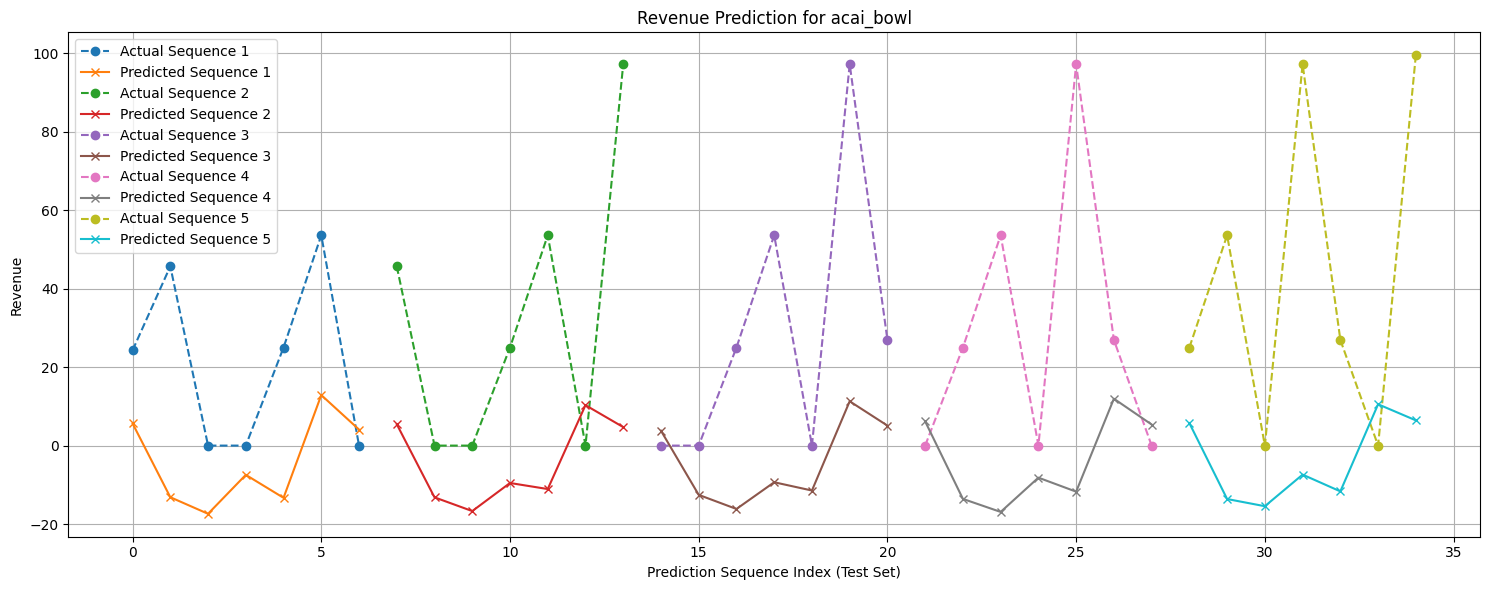

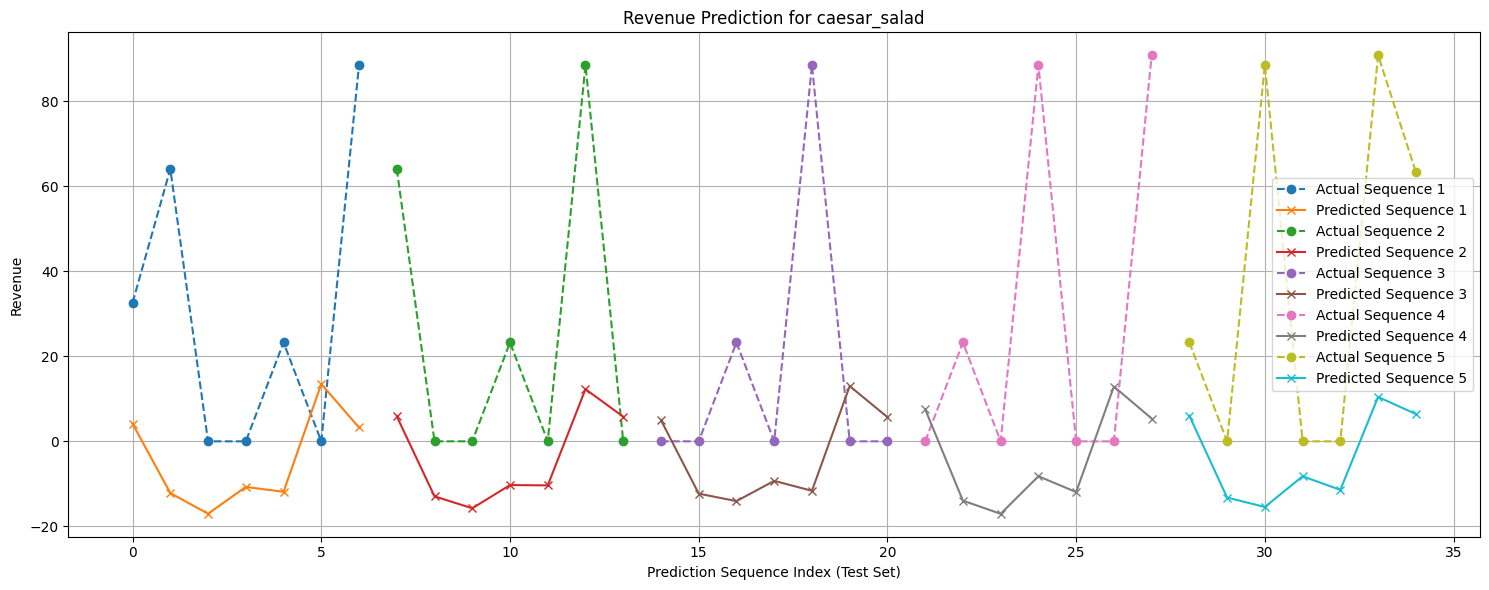

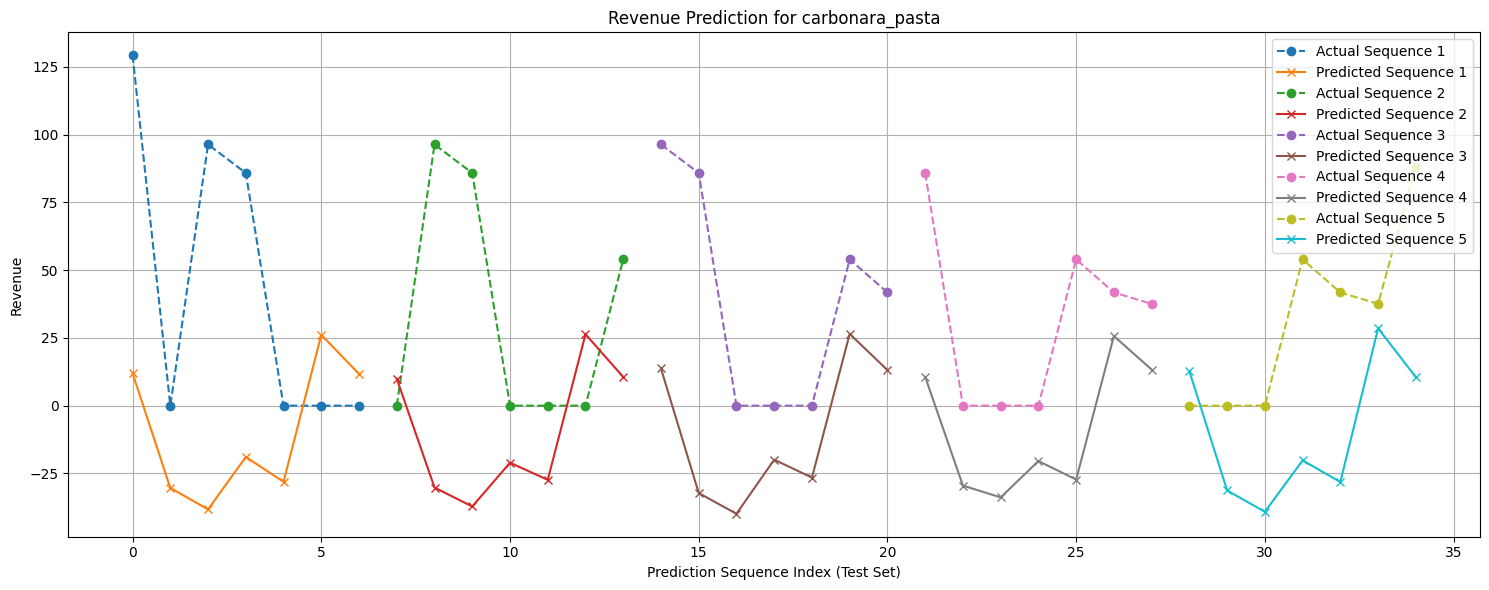

In [ ]:
def plot_predictions(product_name, predictions, actuals, forecast_horizon=FORECAST_HORIZON):
    plt.figure(figsize=(15, 6))
    plt.title(f'Revenue Prediction for {product_name}')
    plt.xlabel('Prediction Sequence Index (Test Set)')
    plt.ylabel('Revenue')

    if product_name in predictions and product_name in actuals:
        # Flatten predictions and actuals for easier plotting if there are many sequences
        # For simplicity, let's plot the first few predictions
        num_plots = min(5, len(predictions[product_name])) # Plot up to 5 sequences

        for i in range(num_plots):
            plt.plot(range(i * forecast_horizon, (i + 1) * forecast_horizon), actuals[product_name][i], label=f'Actual Sequence {i+1}', marker='o', linestyle='--')
            plt.plot(range(i * forecast_horizon, (i + 1) * forecast_horizon), predictions[product_name][i], label=f'Predicted Sequence {i+1}', marker='x')

        if num_plots == 0:
            print(f"No test data to plot for {product_name}")

    else:
        print(f"No predictions found for {product_name}")

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot for a few example products
products_to_plot = unique_products[:3] # Plot the first 3 products

for product in products_to_plot:
    plot_predictions(product, product_predictions, product_actuals)


### 8. Diagnostic: Checking for Overfitting and Real-World Error

To see if the model is overfitting, we look for a gap where Training Loss continues to drop but Validation Loss starts to rise. We will also calculate the **MAE** to see the error in currency units.

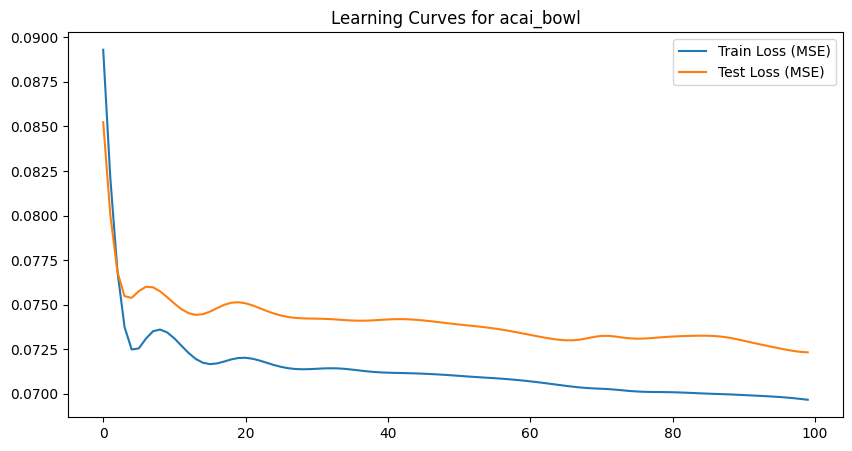

--- Metrics for acai_bowl ---
Mean Absolute Error (MAE): R$ 25.67
Root Mean Squared Error (RMSE): R$ 35.00


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Let's re-train one sample product and track the history to check for overfitting
example_product = unique_products[0]
item = next(s for s in all_product_sequences if s['product'] == example_product)

X_train, y_train = train_sequences[0]['X'].to(device), train_sequences[0]['y'].to(device)
X_test, y_test = test_sequences[0]['X'].to(device), test_sequences[0]['y'].to(device)

diagnostic_model = ProductRNN(input_size, hidden_size, output_size, num_layers).to(device)
optimizer = torch.optim.Adam(diagnostic_model.parameters(), lr=0.001)
criterion = nn.MSELoss()

history = {'train_loss': [], 'test_loss': []}

for epoch in range(100):
    diagnostic_model.train()
    optimizer.zero_grad()
    outputs = diagnostic_model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    diagnostic_model.eval()
    with torch.no_grad():
        test_outputs = diagnostic_model(X_test)
        t_loss = criterion(test_outputs, y_test)

    history['train_loss'].append(loss.item())
    history['test_loss'].append(t_loss.item())

# Plotting the loss curves
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss (MSE)')
plt.plot(history['test_loss'], label='Test Loss (MSE)')
plt.title(f'Learning Curves for {example_product}')
plt.legend()
plt.show()

# Calculate Error in Reais (using MAE)
scaler = scalers[example_product]
final_preds = scaler.inverse_transform(test_outputs.cpu().numpy())
final_actuals = scaler.inverse_transform(y_test.cpu().numpy())

mae = mean_absolute_error(final_actuals, final_preds)
rmse = np.sqrt(mean_squared_error(final_actuals, final_preds))

print(f"--- Metrics for {example_product} ---")
print(f"Mean Absolute Error (MAE): R$ {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): R$ {rmse:.2f}")


### 3. Data Preparation for RNN

To use the aggregated daily product revenue data for an RNN model, we need to perform several steps:
1.  **Ensure Data Continuity**: Make sure there are no missing dates for each product. If a product had no sales on a particular day, its revenue for that day should be 0.
2.  **Normalization**: Scale the revenue data, which helps RNNs converge faster and perform better.
3.  **Sequence Creation**: Transform the time series into sequences of input (features) and target (labels). For predicting 7 days ahead, we'll create sequences where a certain number of past days (e.g., 30 days) predict the next 7 days.
4.  **Train-Test Split**: Divide the sequences into training and testing sets.


In [ ]:
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

# Sort the data to ensure correct time series order
daily_product_revenue = daily_product_revenue.sort_values(by=['main_dish', 'date'])

# Define sequence parameters
LOOK_BACK = 30 # Number of past days to consider for prediction
FORECAST_HORIZON = 7 # Number of future days to predict

# Prepare data for each product
all_product_sequences = []
scalers = {}

for product in unique_products:
    product_df = daily_product_revenue[daily_product_revenue['main_dish'] == product].copy()

    # Ensure all dates are present and fill missing revenue with 0
    # Create a full date range for the product's existence
    if not product_df.empty:
        min_date = product_df['date'].min()
        max_date = product_df['date'].max()
        full_date_range = pd.date_range(start=min_date, end=max_date, freq='D').date
        full_df = pd.DataFrame({'date': full_date_range})
        full_df['main_dish'] = product

        product_df = pd.merge(full_df, product_df, on=['date', 'main_dish'], how='left')
        product_df['total_daily_revenue'] = product_df['total_daily_revenue'].fillna(0)
        product_df = product_df.sort_values(by='date').reset_index(drop=True)
    else:
        continue # Skip if no data for the product

    # Normalize the data
    scaler = MinMaxScaler(feature_range=(0, 1))
    product_df['scaled_revenue'] = scaler.fit_transform(product_df[['total_daily_revenue']])
    scalers[product] = scaler # Store scaler for inverse transformation later

    # Create sequences
    data_sequence = product_df['scaled_revenue'].values

    X_list, y_list = [], [] # Use _list suffix to avoid name conflict with torch.tensor X, y
    for i in range(len(data_sequence) - LOOK_BACK - FORECAST_HORIZON + 1):
        X_list.append(data_sequence[i:(i + LOOK_BACK)])
        y_list.append(data_sequence[(i + LOOK_BACK):(i + LOOK_BACK + FORECAST_HORIZON)])

    if X_list and y_list:
        # Convert list of arrays to a single numpy array before converting to tensor
        X = torch.tensor(np.array(X_list), dtype=torch.float32).unsqueeze(-1) # Add feature dimension
        y = torch.tensor(np.array(y_list), dtype=torch.float32) # Target is 7 days
        all_product_sequences.append({'product': product, 'X': X, 'y': y})

print(f"Generated sequences for {len(all_product_sequences)} products.")

# Split into training and testing sets (using the last 20% of data for testing)
train_sequences = []
test_sequences = []

for item in all_product_sequences:
    X = item['X']
    y = item['y']
    product = item['product']

    split_idx = int(len(X) * 0.8)

    train_sequences.append({'product': product, 'X': X[:split_idx], 'y': y[:split_idx]})
    test_sequences.append({'product': product, 'X': X[split_idx:], 'y': y[split_idx:]})

print(f"\nTotal training sequences: {sum(len(seq['X']) for seq in train_sequences)} from {len(train_sequences)} products")
print(f"Total testing sequences: {sum(len(seq['X']) for seq in test_sequences)} from {len(test_sequences)} products")

# Example of a single sequence's shape
if train_sequences:
    print(f"\nExample training input shape (X): {train_sequences[0]['X'].shape}") # (batch_size, LOOK_BACK, 1)
    print(f"Example training target shape (y): {train_sequences[0]['y'].shape}") # (batch_size, FORECAST_HORIZON)


Generated sequences for 16 products.

Total training sequences: 1653 from 16 products
Total testing sequences: 416 from 16 products

Example training input shape (X): torch.Size([104, 30, 1])
Example training target shape (y): torch.Size([104, 7])
